##SpectralFormer

In [ ]:
import os
import numpy as np
import pandas as pd
import rasterio
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from einops import rearrange, repeat
from torchvision import transforms

# Define band selection (match training)
BANDS_USED = [3, 4, 6, 7, 8, 11]  # Your selected bands (1-based index)
NUM_CLASSES = 5  # Forest, HerbaceousVegetation, Pasture, River, SeaLake

class EuroSATDataset(Dataset):
    def __init__(self, csv_file, base_path, transform=None):
        self.data = pd.read_csv(csv_file).sample(frac=1).reset_index(drop=True)
        self.base_path = base_path
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_name = self.data.loc[idx, 'Filename']
        label = int(self.data.loc[idx, 'Label'])

        with rasterio.open(os.path.join(self.base_path, img_name)) as src:
            img = np.stack([src.read(b) for b in BANDS_USED], axis=-1).astype(np.float32)

        img = img / 10000.0  # Normalize
        img = torch.tensor(img).permute(2, 0, 1)  # (H, W, C) -> (C, H, W)

        if self.transform:
            img = self.transform(img)

        return img, label

# SpectralFormer Components
class SpectralAttention(nn.Module):
    """Spectral attention module that captures cross-band relationships"""
    def __init__(self, dim, num_heads=8):
        super().__init__()
        self.num_heads = num_heads
        self.scale = (dim // num_heads) ** -0.5
        
        self.to_qkv = nn.Linear(dim, dim * 3)
        self.to_out = nn.Linear(dim, dim)

    def forward(self, x):
        b, n, d = x.shape
        qkv = self.to_qkv(x).chunk(3, dim=-1)
        q, k, v = map(lambda t: rearrange(t, 'b n (h d) -> b h n d', h=self.num_heads), qkv)
        
        dots = torch.matmul(q, k.transpose(-1, -2)) * self.scale
        attn = dots.softmax(dim=-1)
        
        out = torch.matmul(attn, v)
        out = rearrange(out, 'b h n d -> b n (h d)')
        return self.to_out(out)

class SpectralTransformerBlock(nn.Module):
    """Spectral Transformer Block with spectral attention and MLP"""
    def __init__(self, dim, num_heads, mlp_dim=128, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = SpectralAttention(dim, num_heads)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, dim),
            nn.Dropout(dropout)
        )
    def forward(self, x):
        x = self.attn(self.norm1(x)) + x
        x = self.mlp(self.norm2(x)) + x
        return x

class SpectralFormer(nn.Module):
    """Complete SpectralFormer implementation"""
    def __init__(self, input_channels=6, patch_size=4, num_classes=5, 
                 dim=64, depth=4, heads=8, mlp_dim=128):
        super().__init__()
        
        # Spectral Grouping (group bands into 2 sets)
        self.group1 = nn.Sequential(
            nn.Conv2d(3, dim//2, kernel_size=1),  # First 3 bands
            nn.GELU())
        self.group2 = nn.Sequential(
            nn.Conv2d(input_channels-3, dim//2, kernel_size=1),  # Last 3 bands
            nn.GELU())
        
        # Patch embedding
        self.patch_embed = nn.Conv2d(dim, dim, kernel_size=patch_size, stride=patch_size)
        
        # Spectral Transformer blocks
        self.spectral_transformer = nn.Sequential(
            *[SpectralTransformerBlock(dim, heads, mlp_dim) for _ in range(depth)])
        
        # Classification head
        self.classifier = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, num_classes))
        
        # Positional embeddings
        self.pos_embedding = nn.Parameter(torch.randn(1, (64//patch_size)**2, dim))
        
    def forward(self, x):
        # Split into spectral groups
        x1 = self.group1(x[:, :3])  # First 3 bands
        x2 = self.group2(x[:, 3:])  # Last 3 bands
        x = torch.cat([x1, x2], dim=1)
        
        # Patch embedding
        x = self.patch_embed(x)
        b, c, h, w = x.shape
        x = rearrange(x, 'b c h w -> b (h w) c')
        
        # Add positional embeddings
        x += self.pos_embedding
        
        # Spectral transformer
        x = self.spectral_transformer(x)
        
        # Global average pooling and classify
        x = x.mean(dim=1)
        return self.classifier(x)

# Training Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dataset and DataLoader
CSV_FILE = r"train.csv"
BASE_PATH = r"EuroSAT AllBands Dataset (Rajasthan Region Alone)"
train_dataset = EuroSATDataset(CSV_FILE, BASE_PATH)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# Model, Loss, Optimizer
model = SpectralFormer(input_channels=6, num_classes=5).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

# Training Loop
num_epochs = 20
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    scheduler.step()
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss/len(train_loader):.4f}")

# Save model
torch.save(model.state_dict(), "true_spectralformer_weights.pth")


Test Accuracy: 0.9570

Classification Report:
                       precision    recall  f1-score   support

              Forest       0.95      0.98      0.96       450
HerbaceousVegetation       0.94      0.93      0.94       450
             Pasture       0.91      0.89      0.90       300
               River       0.98      0.97      0.97       375
             SeaLake       0.99      1.00      1.00       450

            accuracy                           0.96      2025
           macro avg       0.95      0.95      0.95      2025
        weighted avg       0.96      0.96      0.96      2025



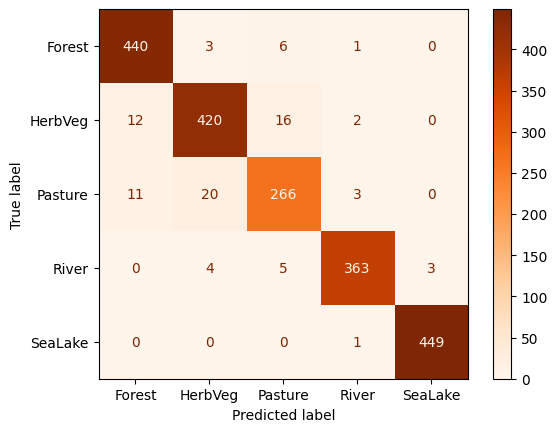

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# Evaluation Function (same as before)
def evaluate_model(model, test_loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Metrics calculation (same as before)
    acc = accuracy_score(all_labels, all_preds)
    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=[
        "Forest", "HerbaceousVegetation", "Pasture", "River", "SeaLake"])
    
    print(f"\nTest Accuracy: {acc:.4f}")
    print("\nClassification Report:\n", report)
    #plot_confusion_matrix(cm, ["Forest", "HerbVeg", "Pasture", "River", "SeaLake"])
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Forest", "HerbVeg", "Pasture", "River", "SeaLake"]).plot(cmap="Oranges")


# Test Evaluation
TEST_CSV_FILE = r"test.csv"
test_dataset = EuroSATDataset(TEST_CSV_FILE, BASE_PATH)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)
evaluate_model(model, test_loader, device)

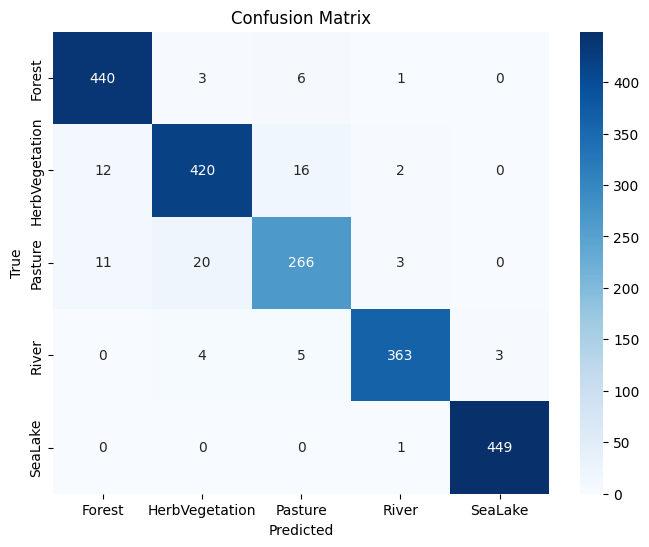


📊 Classification Report:
                precision    recall  f1-score   support

        Forest     0.9503    0.9778    0.9639       450
HerbVegetation     0.9396    0.9333    0.9365       450
       Pasture     0.9078    0.8867    0.8971       300
         River     0.9811    0.9680    0.9745       375
       SeaLake     0.9934    0.9978    0.9956       450

      accuracy                         0.9570      2025
     macro avg     0.9544    0.9527    0.9535      2025
  weighted avg     0.9569    0.9570    0.9569      2025



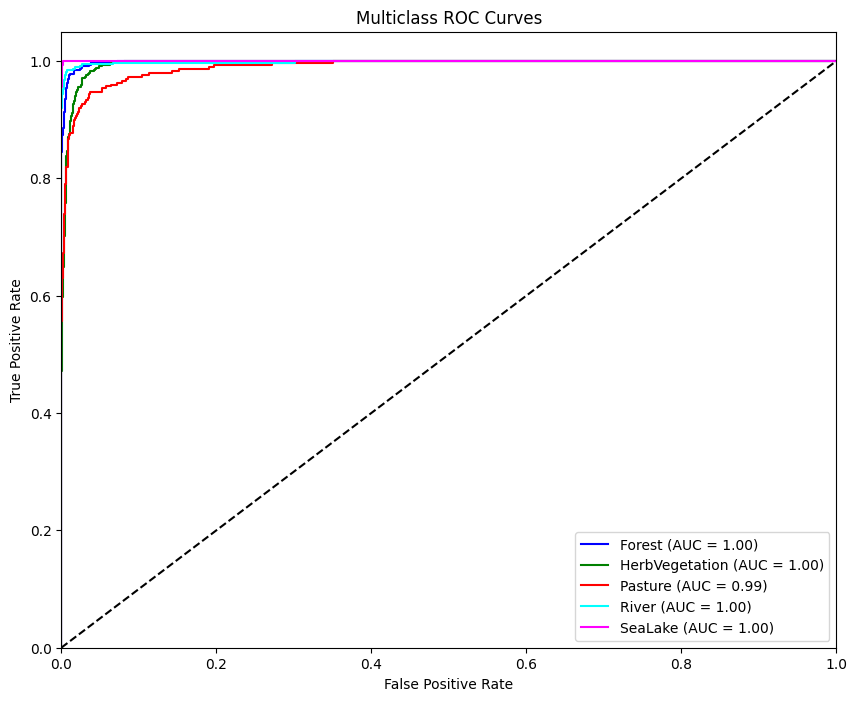


🧮 Performance Metrics Summary:
Accuracy: 0.9570
Balanced Acc: 0.9527
Precision: 0.9569
Recall: 0.9570
F1-Score: 0.9569
Kappa: 0.9460
AUC-OVR: 0.9966


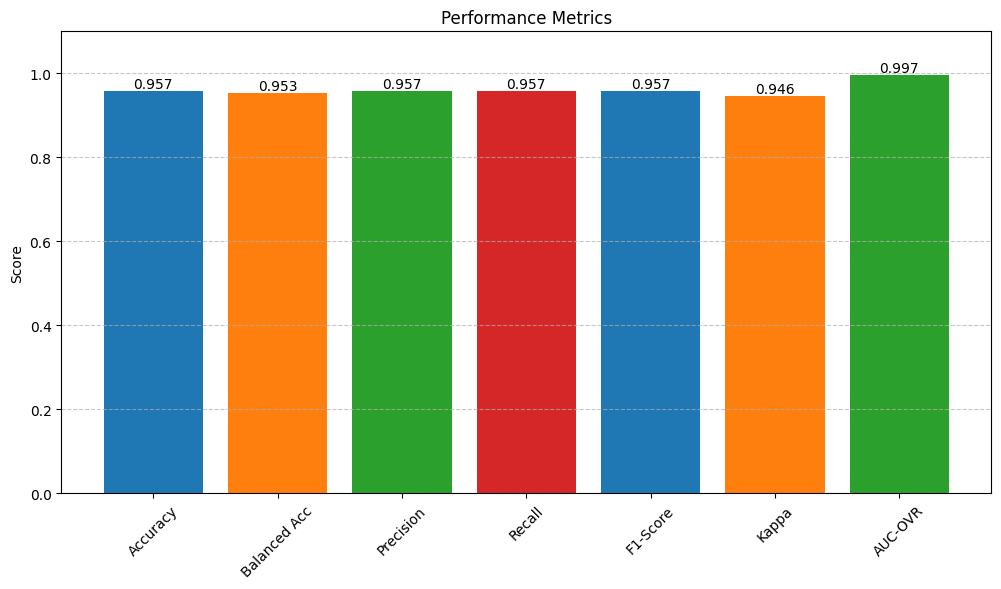

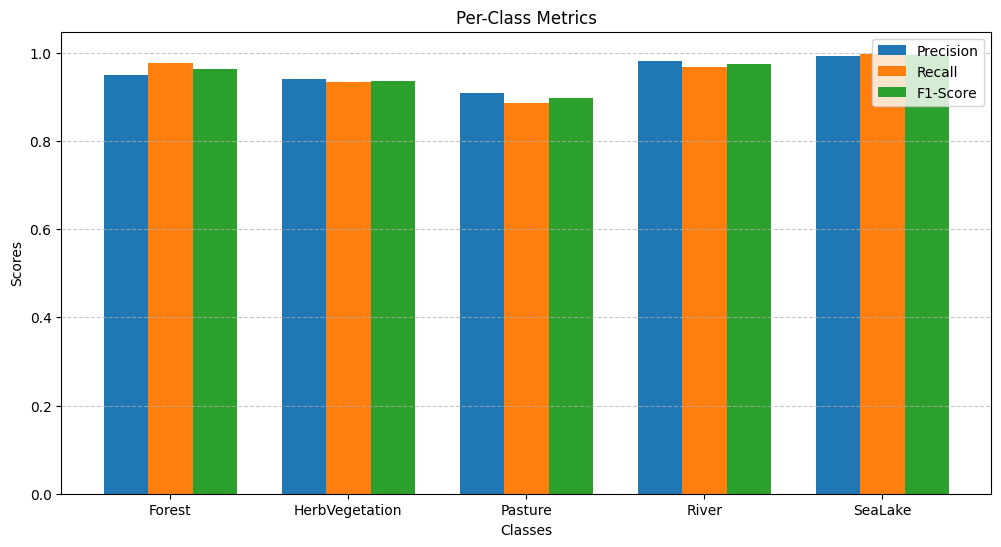

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_recall_fscore_support, roc_curve, auc, 
    roc_auc_score, cohen_kappa_score, balanced_accuracy_score
)
from sklearn.preprocessing import label_binarize
import numpy as np

def plot_roc_auc_multiclass(y_true, y_pred_prob, class_names):
    """Plot ROC curves for each class and compute AUC"""
    # Binarize the output
    y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
    
    # Compute ROC curve and ROC area for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    plt.figure(figsize=(10, 8))
    colors = ['blue', 'green', 'red', 'cyan', 'magenta']
    
    for i in range(len(class_names)):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        plt.plot(fpr[i], tpr[i], color=colors[i],
                 label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multiclass ROC Curves')
    plt.legend(loc="lower right")
    plt.show()
    
    return roc_auc

def plot_metrics_barchart(metrics_dict, title="Performance Metrics"):
    """Plot bar chart for multiple metrics"""
    metrics_names = list(metrics_dict.keys())
    values = list(metrics_dict.values())
    
    plt.figure(figsize=(12, 6))
    bars = plt.bar(metrics_names, values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
    
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.3f}',
                 ha='center', va='bottom')
    
    plt.ylim(0, 1.1)
    plt.title(title)
    plt.ylabel('Score')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

def comprehensive_evaluation(model, test_loader, device):
    """Enhanced evaluation with multiple metrics and visualizations"""
    model.eval()
    all_preds = []
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Convert to numpy arrays
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)
    
    # Class names
    class_names = ["Forest", "HerbVegetation", "Pasture", "River", "SeaLake"]
    
    # 1. Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()
    
    # 2. Classification Report
    print("\n📊 Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))
    
    # 3. ROC-AUC Curves
    roc_auc_scores = plot_roc_auc_multiclass(all_labels, all_probs, class_names)
    
    # 4. Calculate additional metrics
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted')
    kappa = cohen_kappa_score(all_labels, all_preds)
    balanced_acc = balanced_accuracy_score(all_labels, all_preds)
    overall_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
    
    # 5. Metrics Summary
    metrics_dict = {
        'Accuracy': accuracy_score(all_labels, all_preds),
        'Balanced Acc': balanced_acc,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Kappa': kappa,
        'AUC-OVR': overall_auc
    }
    
    print("\n🧮 Performance Metrics Summary:")
    for metric, value in metrics_dict.items():
        print(f"{metric}: {value:.4f}")
    
    # 6. Metrics Bar Chart
    plot_metrics_barchart(metrics_dict)
    
    # 7. Per-class metrics
    class_metrics = precision_recall_fscore_support(all_labels, all_preds, average=None)
    plt.figure(figsize=(12, 6))
    x = np.arange(len(class_names))
    width = 0.25
    
    plt.bar(x - width, class_metrics[0], width, label='Precision')
    plt.bar(x, class_metrics[1], width, label='Recall')
    plt.bar(x + width, class_metrics[2], width, label='F1-Score')
    
    plt.xlabel('Classes')
    plt.ylabel('Scores')
    plt.title('Per-Class Metrics')
    plt.xticks(x, class_names)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
    
    return metrics_dict

# Run comprehensive evaluation
metrics = comprehensive_evaluation(model, test_loader, device)